# How have Airbnb prices changed due to COVID-19?

## Business Understanding

This is the most recent data (Oct, 2020) taken from the official website Airbnb http://insideairbnb.com/get-the-data.html

In this Notebook, we'll look at this data, clean up, analyze, visualize, and model.

And we will answer the following questions for Business Understanding:

1. What correlates best with the price?

2. How has price and busyness changed over the course of COVID-19?

4. Can we predict the price based on its features?

Let's begin!

In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

#ml libraries
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
from xgboost import plot_importance

from keras import backend as K
import tensorflow as tf
import time
from tensorflow import keras
from keras import models, layers, optimizers, regularizers
from IPython.display import SVG
from keras.utils.vis_utils import model_to_dot
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import learning_curve
from sklearn.preprocessing import StandardScaler, MinMaxScaler
#metrics
from sklearn.metrics import r2_score, mean_squared_error

%matplotlib inline

Using TensorFlow backend.


In [2]:
def printColunmsInfo(df):
    '''takes dataframe, prints columns info'''
    df.info()
    print("\n")
    printTotalRowsAndColumns(df)
    print("---------------------------------------")
    
def printTotalRowsAndColumns(df):
    '''print number of columns and rows'''
    print("Total columns: ", df.shape[1])
    print("Total rows: ", df.shape[0])

In [3]:
def stringToNumConverter(string):
    '''deletes not numbers symbols from string'''
    newString = ""
    if pd.notna(string):
        for i in string:
            if i.isdigit() or i == ".":
                newString += i            
    return newString

In [4]:
def create_dummy_df(df, cat_cols, dummy_na):
    '''creates dummy'''
    for col in  cat_cols:
        try:
            # for each cat add dummy var, drop original column
            df = pd.concat([df.drop(col, axis=1), pd.get_dummies(df[col], prefix=col, prefix_sep='_', drop_first=True, dummy_na=dummy_na)], axis=1)
        except:
            continue
    return df

In [5]:
def dateToCategorical(row):
    '''changes column from date type to categorical'''
    if row.year <= 2016:
        return "4+ years"
    elif row.year <= 2018:
        return "2-3 years"
    elif row.year <= 2019:
        return "1-2 years"
    elif row.year == 2020:
        if row.month > 8:
            return "0-1 month"
        elif row.month > 2:
            return "2-6 months"
        elif row.month <= 2:
            return "this year"
    else :
        return "no reviews"   

In [6]:
def appendToMetricsdf(df, model_name, train_r2, test_r2, train_mse, test_mse):
    '''appends new row to metrics_df'''
    new_row = {"Model Name" : model_name,
               "r-squared train" : train_r2,
               "r-squared train test" : test_r2,
               "MSE train" : train_mse,
               "MSE test" : test_mse }

    df = df.append(new_row, ignore_index=True)
    return df

In [7]:
def r2_keras(y_true, y_pred):
    '''calculates r2_score'''
    SS_res =  K.sum(K.square(y_true - y_pred)) 
    SS_tot = K.sum(K.square(y_true - K.mean(y_true))) 
    return (1 - SS_res/(SS_tot + K.epsilon()) )

In [8]:
#load data
sf_cal = pd.read_csv("datasets/calendar.csv", low_memory=False, index_col=0)
sf_list = pd.read_csv("datasets/listings.csv")

N:\Anaconda\lib\site-packages\numpy\lib\arraysetops.py:569: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  mask |= (ar1 == a)


## Cleaning the Data

### Listing Data Frame

First, let's look on Listing Data Frame. It is the biggest table. We won't need some columns because they don't make much sense for our purposes. So we will drop them.

In [9]:
sf_list = sf_list[['id', 'host_since', 'host_is_superhost', 'host_listings_count', 'host_response_time', 
                   'host_response_rate', 'host_acceptance_rate','neighbourhood_cleansed', 'latitude', 'longitude', 
                   'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'amenities', 
                   'minimum_nights', 'maximum_nights', 'review_scores_rating', 'review_scores_accuracy', 
                   'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 
                   'review_scores_location', 'review_scores_value', 'availability_30', 'number_of_reviews',
                   'last_review', 'reviews_per_month', 'price']]
sf_list.head()

,id,host_since,host_is_superhost,host_listings_count,host_response_time,host_response_rate,host_acceptance_rate,neighbourhood_cleansed,latitude,longitude,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,availability_30,number_of_reviews,last_review,reviews_per_month,price
0,958,2008-07-31,t,1,within an hour,100%,99%,Western Addition,37.76931,-122.43386,...,10.0,10.0,10.0,10.0,10.0,10,257,2020-07-30,1.91,$132.00
1,5858,2009-03-02,f,2,within a day,60%,83%,Bernal Heights,37.74511,-122.42102,...,10.0,10.0,10.0,10.0,9.0,30,111,2017-08-06,0.81,$235.00
2,7918,2009-06-17,f,10,within a few hours,100%,100%,Haight Ashbury,37.76555,-122.45213,...,8.0,9.0,9.0,9.0,8.0,30,19,2020-03-06,0.14,$56.00
3,8142,2009-06-17,f,10,within a few hours,100%,100%,Haight Ashbury,37.76555,-122.45213,...,9.0,10.0,10.0,9.0,9.0,30,8,2018-09-12,0.11,$56.00
4,8339,2009-07-02,f,2,within a few hours,100%,0%,Western Addition,37.77525,-122.43637,...,10.0,10.0,10.0,10.0,10.0,30,28,2019-06-28,0.21,$750.00


We have left the following columns:

* __'id'__ — we'll use to join tables
* __host_since__ and __last_review__ — datatype data, we transform to categorical
* __'host_response_time'__ — categorical data
* __host_is_superhost__ — boolean data
* __'host_response_rate'__ and __'host_acceptance_rate'__ — as a percentage, we will change to integer
* __neighbourhood_cleansed'__ — neighbourhood name
* __'latitude', 'longitude'__ — сoordinates, we use them for visualisation
* __'room_type'__ and __property_type__ — categorical data
* __'accommodates', 'bathrooms', 'bedrooms', 'beds'__ — numerical values describing property
* __'amenities'__ — can be used to identify words associated with amenities
* __'minimum_nights', 'maximum_nights'__ — numerical values
* __'review_scores_rating'__ — numbers between 20 and 100
* __'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', review_scores_communication', 'review_scores_location', 'review_scores_value'__ — numbers between 2 and 10
* __availability_30__, __number_of_reviews__, __reviews_per_month__ — numerical
* __'price'__ — target value

Let's convert string data to numeric.

In [10]:
#converting datatype of price column to integer
sf_list["price"] = sf_list["price"].apply(lambda string: ''.join(i for i in string if i.isdigit())[:-2])
sf_list["price"] = pd.to_numeric(sf_list["price"], downcast="integer")

#host_response_rate and host_acceptance_rate types to float
sf_list["host_response_rate"] = sf_list["host_acceptance_rate"].apply(lambda string: stringToNumConverter(string))
sf_list["host_response_rate"] = pd.to_numeric(sf_list["host_response_rate"], downcast="float")

sf_list["host_acceptance_rate"] = sf_list["host_acceptance_rate"].apply(lambda string: stringToNumConverter(string))
sf_list["host_acceptance_rate"] = pd.to_numeric(sf_list["host_acceptance_rate"], downcast="float")

#converting t, f value to 1 or 0
sf_list["host_is_superhost"] = sf_list["host_is_superhost"].apply((lambda string: 1 if string == "t" else 0))

#converting datatype of date columns to datetime
sf_list["last_review"] = pd.to_datetime(arg=sf_list["last_review"], errors="coerce")
sf_list["host_since"] = pd.to_datetime(arg=sf_list["host_since"], errors="coerce")


In [11]:
print("Listing Data Frame")
printColunmsInfo(sf_list)

Listing Data Frame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7274 entries, 0 to 7273
Data columns (total 31 columns):
id                             7274 non-null int64
host_since                     7274 non-null datetime64[ns]
host_is_superhost              7274 non-null int64
host_listings_count            7274 non-null int64
host_response_time             5321 non-null object
host_response_rate             6393 non-null float32
host_acceptance_rate           6393 non-null float32
neighbourhood_cleansed         7274 non-null object
latitude                       7274 non-null float64
longitude                      7274 non-null float64
property_type                  7274 non-null object
room_type                      7274 non-null object
accommodates                   7274 non-null int64
bathrooms                      7185 non-null float64
bedrooms                       6430 non-null float64
beds                           7234 non-null float64
amenities                      

### Amenities Data Frame

Consider the data about the amenities. This column is a set of lists enclosed in strings. So I had to use the *eval*. If you know a more elegant method, please let me know.

Then we'll add columns for each amenitie, remove the common and very rare amenities.

In [12]:
amenitiesList = []
for item in sf_list["amenities"].value_counts().reset_index()["index"]:
    item = eval(item)
    for i in item:
        if i not in amenitiesList:
            amenitiesList.append(i)
print("Total amenities: ", len(amenitiesList))
print(amenitiesList)

Total amenities:  131
['Gym', 'Heating', 'Hot water', 'Air conditioning', 'Iron', 'Dryer', 'Carbon monoxide alarm', 'Building staff', 'Luggage dropoff allowed', 'Private entrance', 'Microwave', 'Hangers', 'Essentials', 'Smoke alarm', 'Refrigerator', 'Wifi', 'Shampoo', 'TV', 'Hair dryer', 'Washer', 'Cable TV', 'Bed linens', 'Stove', 'Coffee maker', 'Elevator', 'Laptop-friendly workspace', 'Extra pillows and blankets', 'Cooking basics', 'Dishes and silverware', 'Long term stays allowed', 'Kitchen', 'Oven', 'Dishwasher', 'BBQ grill', 'Host greets you', 'Free street parking', 'Hot tub', 'First aid kit', 'Fire extinguisher', 'Lock on bedroom door', 'Paid parking on premises', 'Lockbox', 'Bathtub', 'Garden or backyard', 'Patio or balcony', 'Indoor fireplace', 'Keypad', 'Cleaning before checkout', 'Paid parking off premises', 'Smart lock', 'Free parking on premises', 'Bread maker', 'Shower gel', 'Crib', 'Baking sheet', 'Breakfast', 'Pool', 'Pocket wifi', 'Ethernet connection', 'Pack ’n Play/t

In [13]:
amenities_df = sf_list[["id", "amenities"]]

#we don't need "amenities" in original data frame anymore
sf_list.drop(["amenities"], axis=1, inplace=True)

In [14]:
amenitiesDict = {}
for item in range(amenities_df.shape[0]):
    i_id, amenitiesSet = amenities_df.loc[item, "id"], set(eval(amenities_df.loc[item, "amenities"]))
    amenitiesDict[i_id] = amenitiesSet

for amenitie in amenitiesList:
    bilist = []
    for amId in amenities_df["id"]: 
        if amenitie in amenitiesDict[amId]:
            bilist.append(1)
        else:
            bilist.append(0)
    amenities_df.insert(loc=len(amenities_df.columns), column=amenitie, value=bilist, allow_duplicates=True)
print(amenities_df.shape)

(7274, 133)


### Calendar Data Frame

In [15]:
sf_cal.head()

,listing_id,date,available,price,adjusted_price,minimum_nights,maximum_nights
0,25662,2020-09-08,t,$125.00,$125.00,4.0,180.0
1,25662,2020-09-09,t,$125.00,$125.00,4.0,180.0
2,25662,2020-09-10,t,$126.00,$126.00,4.0,180.0
3,25662,2020-09-11,t,$139.00,$139.00,4.0,180.0
4,25662,2020-09-12,t,$151.00,$151.00,4.0,180.0


This Data Frame has folowing columns:
* __listing_id__ — id values, we'll use to join tables
* __date__ — we need to change datatype to datetime
* __available__ — it has to be boolean, so we need to change it
* __minimum_nights, maximum_nights__ — we have same columns in Listing Data Frame, drop they later
* __adjusted_price__, __price__ — target values

In [16]:
#converting datatype of price and adjusted_price columns to integer
sf_cal["price"] = sf_cal["price"].apply(lambda string: stringToNumConverter(string))
sf_cal["price"] = pd.to_numeric(sf_cal["price"], downcast="integer")

sf_cal["adjusted_price"] = sf_cal["adjusted_price"].apply(lambda string: stringToNumConverter(string))
sf_cal["adjusted_price"] = pd.to_numeric(sf_cal["adjusted_price"], downcast="integer")

#converting datatype of date columns to datetime
sf_cal["date"] = pd.to_datetime(arg=sf_cal["date"], errors="coerce")

#converting t, f value to Boolean datatype
sf_cal["available"] = sf_cal["available"].apply((lambda string: True if string == "t" else False))

In [17]:
print("Calendar Data Frame")
printColunmsInfo(sf_cal)

Calendar Data Frame
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2390652 entries, 0 to 2390651
Data columns (total 7 columns):
listing_id        int64
date              datetime64[ns]
available         bool
price             float64
adjusted_price    float64
minimum_nights    float64
maximum_nights    float64
dtypes: bool(1), datetime64[ns](1), float64(4), int64(1)
memory usage: 130.0 MB


Total columns:  7
Total rows:  2390652
---------------------------------------


## Data Understanding

Let's analyze the data to answer the questions given at the beginning:
#### 1. What correlates best with price?

##### Does Amenities correlate with price?

In [18]:
amen_price_corr_neg = amenities_df.merge(sf_list[["id", "price"]], on="id").corr()[["id", "price"]].sort_values(by="price").head(10)
amen_price_corr_pos = amenities_df.merge(sf_list[["id", "price"]], on="id").corr()[["id", "price"]].sort_values(by="price").drop("price", axis=0).tail(10)

In [19]:
#negative correlation
amen_price_corr_neg.drop("id", axis=1).style.bar(color="#00677e", align="mid")

,price
Laptop-friendly workspace,-0.107526
Kitchen,-0.102176
Lock on bedroom door,-0.0904803
Fire extinguisher,-0.0715439
Dishes and silverware,-0.0659627
Long term stays allowed,-0.0633037
Coffee maker,-0.055081
Extra pillows and blankets,-0.0528781
Free street parking,-0.0524836
Cooking basics,-0.0520336


In [20]:
#positive correlation
amen_price_corr_pos.drop("id", axis=1).style.bar(color="#cd4a4c")

,price
Walk in closet,0.0873672
Luggage dropoff allowed,0.0883892
Private entrance,0.0901716
Shower bathtub combo,0.090372
Stand alone rain shower,0.0937878
Dual vanity,0.0938235
Cable TV,0.104391
Gym,0.179249
Air conditioning,0.180001
Building staff,0.255858


As you can see, air conditioning, gym, and building staff are highly correlated with price. The rest of the amenities correlate either weakly or not at all.

##### Does Review Scores correlate with price?

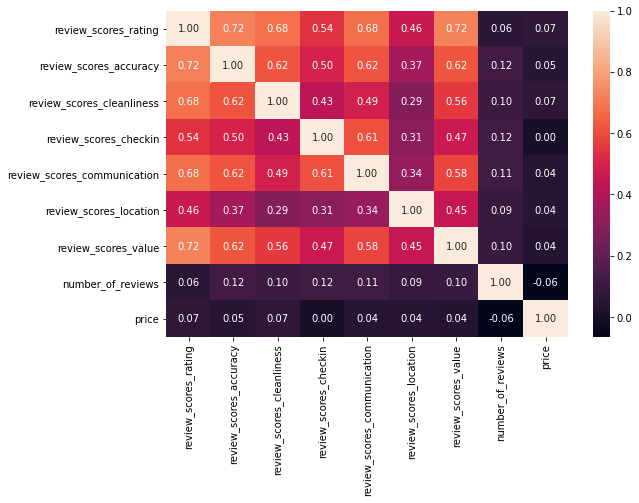

In [21]:
plt.subplots(figsize=(9, 6))
sns.heatmap(sf_list[['review_scores_rating', 'review_scores_accuracy',
                     'review_scores_cleanliness', 'review_scores_checkin',
                     'review_scores_communication', 'review_scores_location',
                     'review_scores_value', "number_of_reviews", 'price']].corr(),
            annot=True, fmt=".2f")

Review Scores correlate weakly with price, but they correlate well with each other.

##### Does Housing Characteristics correlate with price?

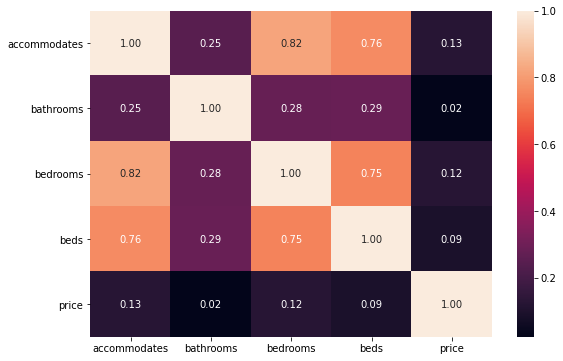

In [22]:
plt.subplots(figsize=(9, 6))
sns.heatmap(sf_list[['accommodates', 'bathrooms', 'bedrooms', 'beds', 'price']].corr(),
            annot=True, fmt=".2f")

There is an obvious correlation. The more people you can accommodate, the more expensive it is to rent a room. Same about bedrooms and beds. But the number of bathrooms does not have a strong impact.

Some more dependencies on the price, which we will use in modeling:

In [23]:
sf_list.groupby(["room_type"]).mean().reset_index()[["room_type","price"]].style.bar(color="#cd4a4c")

,room_type,price
0,Entire home/apt,324.781
1,Hotel room,278.821
2,Private room,129.865
3,Shared room,87.2024


In [24]:
sf_list.groupby(["property_type"]).mean().reset_index()[["property_type","price"]].sort_values(by="price", ascending=False).style.bar(color="#cd4a4c")

,property_type,price
18,Entire villa,2361.86
14,Entire loft,1716.64
34,Private room in resort,1061.46
2,Castle,1035.5
17,Entire townhouse,445.474
3,Earth house,405
12,Entire house,392.54
35,Private room in serviced apartment,311.667
4,Entire apartment,304.559
7,Entire condominium,302.477


In [25]:
sf_list.groupby(["host_response_time"]).mean().reset_index()[["host_response_time","price"]].style.bar(color="#cd4a4c")

,host_response_time,price
0,a few days or more,183.075
1,within a day,230.325
2,within a few hours,186.6
3,within an hour,284.239


In [26]:
sf_list.groupby(["host_is_superhost"]).mean().reset_index()[["host_is_superhost","price"]]

,host_is_superhost,price
0,0,206.023579
1,1,297.049307


In [27]:
sf_list[["number_of_reviews","price"]].corr()

,number_of_reviews,price
number_of_reviews,1.000000,-0.064426
price,-0.064426,1.000000


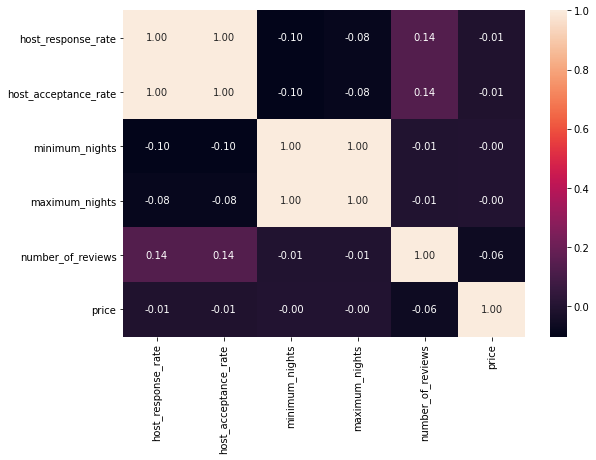

In [28]:
plt.subplots(figsize=(9, 6))
sns.heatmap(sf_list[["host_response_rate", "host_acceptance_rate", "minimum_nights",
                             "maximum_nights", "number_of_reviews", "price"]].corr(),
            annot=True, fmt=".2f")

##### How about Neighbourhoods?

Let's find the most expensive neighbourhood.

In [29]:
#coordinates of San Francisco
sf_latitude, sf_longitude = 37.7647993, -122.4629897
#the necessary data for the map
sf_map = gpd.read_file("planning_neighborhoods/planning_neighborhoods.shp")
sf_neig_mean = sf_list.groupby(["neighbourhood_cleansed"]).mean().reset_index()
sf_map = sf_map.merge(sf_neig_mean, left_on="neighborho", right_on="neighbourhood_cleansed")

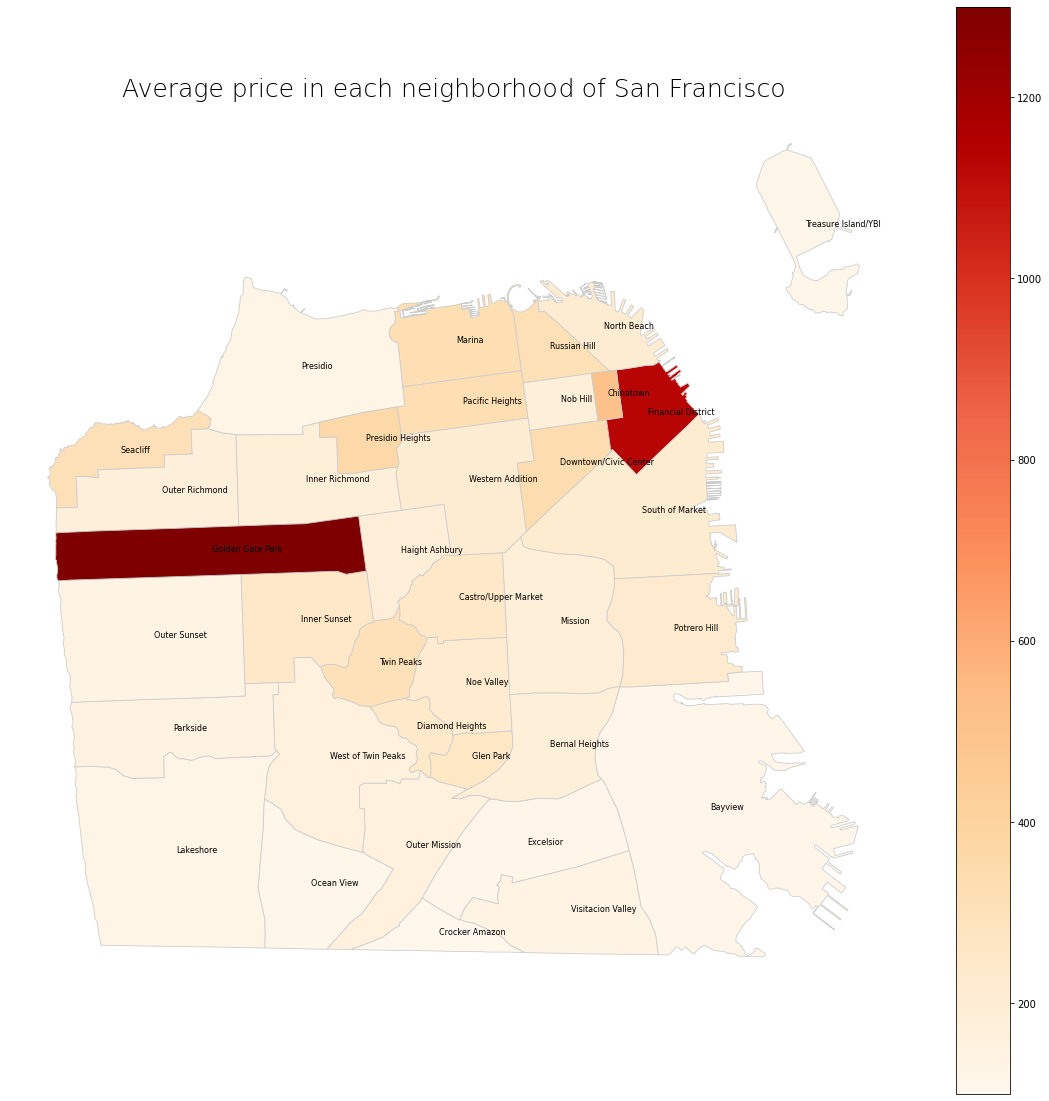

In [30]:
vmin, vmax = 100, 1300

fig, ax = plt.subplots(figsize = (20, 20))
ax.set_title("Average price in each neighborhood of San Francisco", fontdict={"fontsize": "25", "fontweight" : "3"})
sf_map.plot(column="price", cmap="OrRd", linewidth=0.8, ax=ax, edgecolor="0.8")

texts = []
for x, y, label in zip(sf_map.centroid.geometry.x, sf_map.centroid.geometry.y, sf_map["neighbourhood_cleansed"]):
    texts.append(plt.text(x, y, label, fontsize = 8))

sm = plt.cm.ScalarMappable(cmap="OrRd", norm=plt.Normalize(vmin=vmin, vmax=vmax))
# empty array for the data range
sm._A = []
# add the colorbar to the figure
cbar = fig.colorbar(sm)
    
ax.axis("off")
plt.show()

In [31]:
sf_list.groupby(["neighbourhood_cleansed"]).mean().reset_index()[["neighbourhood_cleansed","price"]].sort_values(by="price", ascending=False).style.bar(color="#cd4a4c")

,neighbourhood_cleansed,price
10,Golden Gate Park,1294
8,Financial District,1126.88
3,Chinatown,510.366
28,Presidio Heights,358.72
6,Downtown/Civic Center,341.329
24,Pacific Heights,321.417
15,Marina,320.086
29,Russian Hill,314.379
30,Seacliff,308.5
33,Twin Peaks,303.235


As you can see from the map, the high price is more related to the location. The most expensive areas are Golden Gate Park and Financial District. If you look at my previous research, you understand that Golden Gate Park is quite safe, unlike the Financial District which pretty criminal.

All this data can be used to predict prices. But before that, let's answer the second question.

#### 2. How has price and busyness changed over the course of COVID-19?

Let's start by looking at price changes over the past year.

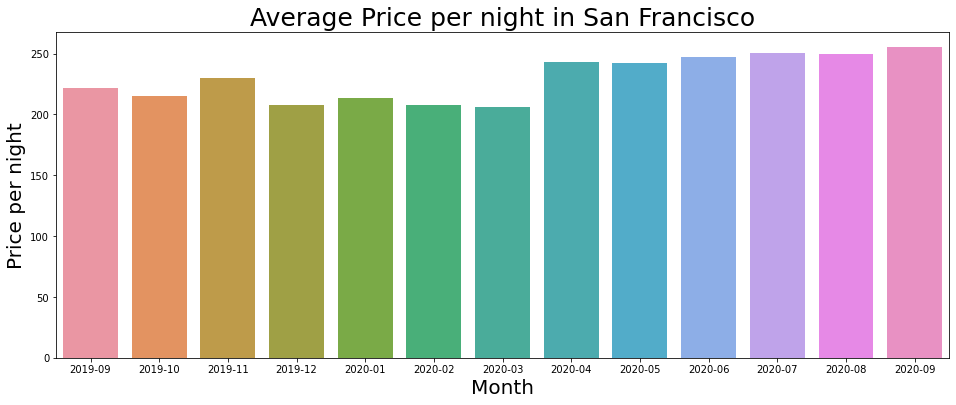

In [32]:
per = sf_cal.date.dt.to_period("M") 
g = sf_cal.groupby(per)

ax = sns.set_palette("viridis")

plt.figure(figsize=(16,6))
sns.barplot(x=g.mean().reset_index()["date"], 
            y=g.mean().reset_index()["price"])
plt.xlabel("Month", fontsize=20)
plt.ylabel("Price per night", fontsize=20)
plt.title("Average Price per night in San Francisco", fontsize=25)

plt.show()

During the covid period, the average price per night rose by about $33. And it does not stop growing linearly.

Next one is busyness.

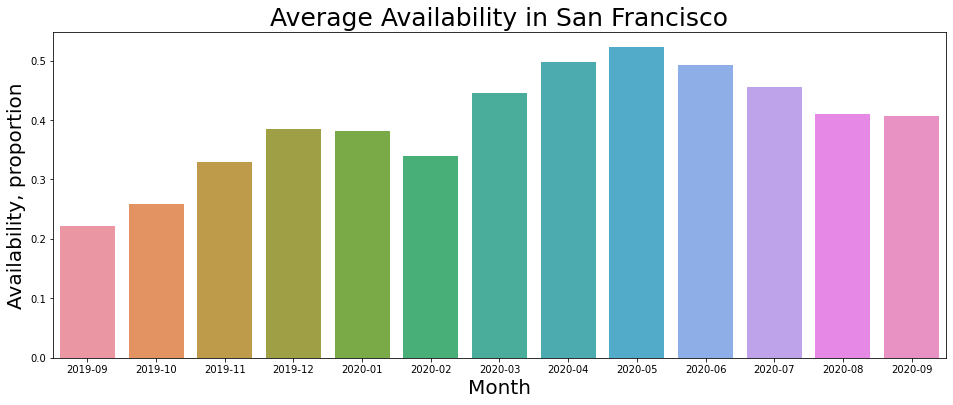

In [33]:
ax = sns.set_palette("viridis")

plt.figure(figsize=(16,6))
sns.barplot(x=g.mean().reset_index()["date"], 
            y=g.mean().reset_index()["available"])
plt.xlabel("Month", fontsize=20)
plt.ylabel("Availability, proportion", fontsize=20)
plt.title("Average Availability in San Francisco", fontsize=25)

plt.show()

September last year was quite popular (wonderful weather). Then the decline began. But with the onset of covid, the decline intensified and reached its peak (half of the housing is vacant) by May.

As expected, the covid did not affect the Airbnb business in the best way. Prices have gone up and there are fewer customers. The indicators have not yet returned to their previous values.

To answer the last question, we have to prepare the data for modeling.

### Can we predict the price based on its features?

## Prepare Data

#### Working with NaNs and categorical variables

Let's turn "last_review" and "host_since" from date type to categorical values. For that, we create new columns and fill them in.

In [34]:
sf_list["since_last_review"] = sf_list["last_review"].apply(lambda row : dateToCategorical(row))
sf_list["host_since_cat"] = sf_list["host_since"].apply(lambda row : dateToCategorical(row))

In [35]:
#drop all Nans in "price" columns
drop_sf_list = sf_list.dropna(subset=["price"], axis=0)
#create data frame with categorical values
cat_sf_list = drop_sf_list[["id", "neighbourhood_cleansed", "room_type",'property_type', "since_last_review", "host_since_cat"]]
#create data frame with nimerical
mean_sf_list = drop_sf_list[["id", "accommodates", "review_scores_rating", "bathrooms", "bedrooms", "beds",
                             "review_scores_accuracy", "review_scores_cleanliness", "availability_30",
                             "number_of_reviews", "reviews_per_month", "review_scores_communication",
                             "review_scores_location", "review_scores_value", "host_is_superhost",
                             "host_listings_count", "price"]]

In [36]:
num_cols = ["accommodates", "review_scores_rating", "bathrooms", "bedrooms", "beds",
            "review_scores_accuracy", "review_scores_cleanliness", "availability_30",
            "number_of_reviews", "reviews_per_month", "review_scores_communication",
            "review_scores_location", "review_scores_value", "host_is_superhost",
            "host_listings_count", "price"]
for col in num_cols:
    mean_sf_list[col] = mean_sf_list[col].astype('float64').replace(0.0, 0.01) 
    mean_sf_list[col] = np.log(mean_sf_list[col])

N:\Anaconda\lib\site-packages\ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  import sys
N:\Anaconda\lib\site-packages\ipykernel_launcher.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  


In [37]:
#fill the mean
fill_mean = lambda col: col.fillna(col.mean())
mean_sf_list = mean_sf_list.apply(fill_mean, axis=0)

In [38]:
#create dummy data frame
cat_cols_lst = ["neighbourhood_cleansed", "room_type",'property_type', "since_last_review", "host_since_cat"]
dummy_sf_list = create_dummy_df(cat_sf_list, cat_cols_lst, dummy_na=False)

After all, we'll merge tree Data Frames: mean_sf_list, dummy_sf_list and amenities_df.

In [39]:
full_sf_list = dummy_sf_list.merge(amenities_df.drop(["amenities"], axis=1), on="id").merge(mean_sf_list, on="id")

## Data Modeling

Let's start modeling. We will try several models and compare the results.

In [40]:
#preparation train and test data
X = full_sf_list.drop(["price"], axis=1)
y = full_sf_list["price"]

#scaling
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=list(X.columns))

#split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=42)

In [41]:
#writing the metrics for every model in DataFrame
metrics_columns = ["Model Name", "r-squared train", "r-squared train test", "MSE train", "MSE test"]
metrics_df = pd.DataFrame(columns=metrics_columns)

## Predicting Price

### AdaBoost regressor

In [42]:
adaboost_model = AdaBoostRegressor(n_estimators=20)
adaboost_model.fit(X_train, y_train)

#predict and score the model
y_test_preds = adaboost_model.predict(X_test)
y_train_preds = adaboost_model.predict(X_train)

#scoring model
test_r2 = round(r2_score(y_test, y_test_preds), 4)
train_r2 = round(r2_score(y_train, y_train_preds), 4)
test_mse = round(mean_squared_error(y_test, y_test_preds), 4)
train_mse = round(mean_squared_error(y_train, y_train_preds), 4)

print('r-squared score for training set was {}. r-squared score for test set was {}.'.format(train_r2, test_r2))
print('MSE score for training set was {}. MSE score for test set was {}.'.format(train_mse, test_mse))

#add row to metrics
metrics_df = appendToMetricsdf(metrics_df, "AdaBoost regressor", train_r2, test_r2, train_mse, test_mse)

r-squared score for training set was 0.4804. r-squared score for test set was 0.4407.
MSE score for training set was 0.3275. MSE score for test set was 0.3551.


### Gradient Boosting for regression

In [43]:
gradboost_model = GradientBoostingRegressor(n_estimators=300)
gradboost_model.fit(X_train, y_train)

#predict and score the model
y_test_preds = gradboost_model.predict(X_test)
y_train_preds = gradboost_model.predict(X_train)

#scoring model
test_r2 = round(r2_score(y_test, y_test_preds), 4)
train_r2 = round(r2_score(y_train, y_train_preds), 4)
test_mse = round(mean_squared_error(y_test, y_test_preds), 4)
train_mse = round(mean_squared_error(y_train, y_train_preds), 4)

print('r-squared score for training set was {}. r-squared score for test set was {}.'.format(train_r2, test_r2))
print('MSE score for training set was {}. MSE score for test set was {}.'.format(train_mse, test_mse))

metrics_df = appendToMetricsdf(metrics_df, "Gradient Boosting", train_r2, test_r2, train_mse, test_mse)

r-squared score for training set was 0.8149. r-squared score for test set was 0.7033.
MSE score for training set was 0.1167. MSE score for test set was 0.1884.


### Extreme Gradient Boosting

In [44]:
xgb_reg = xgb.XGBRegressor()
xgb_reg.fit(X_train, y_train)

y_train_preds = xgb_reg.predict(X_train)
y_test_preds = xgb_reg.predict(X_test)

#scoring model
test_r2 = round(r2_score(y_test, y_test_preds), 4)
train_r2 = round(r2_score(y_train, y_train_preds), 4)
test_mse = round(mean_squared_error(y_test, y_test_preds), 4)
train_mse = round(mean_squared_error(y_train, y_train_preds), 4)

print('r-squared score for training set was {}. r-squared score for test set was {}.'.format(train_r2, test_r2))
print('MSE score for training set was {}. MSE score for test set was {}.'.format(train_mse, test_mse))

metrics_df = appendToMetricsdf(metrics_df, "Extreme Gradient Boosting", train_r2, test_r2, train_mse, test_mse)

[16:43:04] WARNING: src/objective/regression_obj.cu:152: reg:linear is now deprecated in favor of reg:squarederror.


N:\Anaconda\lib\site-packages\xgboost\core.py:587: FutureWarning: Series.base is deprecated and will be removed in a future version
  if getattr(data, 'base', None) is not None and \


r-squared score for training set was 0.7093. r-squared score for test set was 0.6544.
MSE score for training set was 0.1832. MSE score for test set was 0.2195.


### Neural Network

In [45]:
#building the model
model = models.Sequential()
model.add(layers.Dense(128, input_shape=(X_train.shape[1],), activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(1, activation='linear'))

#compiling the model
model.compile(optimizer='adam', 
              loss='mse', 
              metrics=[r2_keras])

#model summary
print(model.summary())

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
dense_1 (Dense)              (None, 128)               32000     
_________________________________________________________________
dense_2 (Dense)              (None, 256)               33024     
_________________________________________________________________
dense_3 (Dense)              (None, 256)               65792     
_________________________________________________________________
dense_4 (Dense)              (None, 1)                 257       
Total params: 131,073
Trainable params: 131,073
Non-trainable params: 0
_________________________________________________________________
None


In [46]:
# Training the model
model_start = time.time()

model_history = model.fit(X_train, y_train, epochs=500, batch_size=256, validation_data=(X_test, y_test))

model_end = time.time()

print(f"Time taken to run: {round((model_end - model_start)/60,1)} minutes")

Train on 5091 samples, validate on 2183 samples
Epoch 1/500
5091/5091 [==============================] - 0s 96us/step - loss: 8.1906 - r2_keras: -12.9687 - val_loss: 2.6318 - val_r2_keras: -3.0942
Epoch 2/500
5091/5091 [==============================] - 0s 22us/step - loss: 1.7102 - r2_keras: -1.7570 - val_loss: 1.1099 - val_r2_keras: -0.7554
Epoch 3/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.6961 - r2_keras: -0.1202 - val_loss: 0.6361 - val_r2_keras: -0.0045
Epoch 4/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.4219 - r2_keras: 0.3275 - val_loss: 0.4637 - val_r2_keras: 0.2656
Epoch 5/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.3061 - r2_keras: 0.5054 - val_loss: 0.3980 - val_r2_keras: 0.3676
Epoch 6/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.2488 - r2_keras: 0.5988 - val_loss: 0.3661 - val_r2_keras: 0.4169
Epoch 7/500
5091/5091 [==============================] - 0s 22us/step

5091/5091 [==============================] - 0s 22us/step - loss: 0.0213 - r2_keras: 0.9660 - val_loss: 0.3083 - val_r2_keras: 0.5068
Epoch 57/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0196 - r2_keras: 0.9691 - val_loss: 0.3062 - val_r2_keras: 0.5109
Epoch 58/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0212 - r2_keras: 0.9670 - val_loss: 0.3082 - val_r2_keras: 0.5069
Epoch 59/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0175 - r2_keras: 0.9721 - val_loss: 0.3065 - val_r2_keras: 0.5097
Epoch 60/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0198 - r2_keras: 0.9700 - val_loss: 0.3064 - val_r2_keras: 0.5116
Epoch 61/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0173 - r2_keras: 0.9730 - val_loss: 0.3095 - val_r2_keras: 0.5049
Epoch 62/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0166 - r2_keras: 0.9750 - val_loss: 0.3060 - val_r

Epoch 112/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0167 - r2_keras: 0.9748 - val_loss: 0.3002 - val_r2_keras: 0.5205
Epoch 113/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0168 - r2_keras: 0.9731 - val_loss: 0.3005 - val_r2_keras: 0.5192
Epoch 114/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0162 - r2_keras: 0.9745 - val_loss: 0.2951 - val_r2_keras: 0.5283
Epoch 115/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0149 - r2_keras: 0.9772 - val_loss: 0.2987 - val_r2_keras: 0.5220
Epoch 116/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0155 - r2_keras: 0.9747 - val_loss: 0.3005 - val_r2_keras: 0.5197
Epoch 117/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0150 - r2_keras: 0.9767 - val_loss: 0.2999 - val_r2_keras: 0.5207
Epoch 118/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0153 - r2_keras: 0.9753 - val_

5091/5091 [==============================] - ETA: 0s - loss: 0.0186 - r2_keras: 0.97 - 0s 23us/step - loss: 0.0160 - r2_keras: 0.9742 - val_loss: 0.2868 - val_r2_keras: 0.5423
Epoch 168/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0167 - r2_keras: 0.9736 - val_loss: 0.2855 - val_r2_keras: 0.5442
Epoch 169/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0175 - r2_keras: 0.9728 - val_loss: 0.2873 - val_r2_keras: 0.5397
Epoch 170/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0149 - r2_keras: 0.9770 - val_loss: 0.2834 - val_r2_keras: 0.5476
Epoch 171/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0150 - r2_keras: 0.9768 - val_loss: 0.2830 - val_r2_keras: 0.5481
Epoch 172/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0151 - r2_keras: 0.9766 - val_loss: 0.2842 - val_r2_keras: 0.5456
Epoch 173/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.01

Epoch 222/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0175 - r2_keras: 0.9717 - val_loss: 0.2753 - val_r2_keras: 0.5609
Epoch 223/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0177 - r2_keras: 0.9716 - val_loss: 0.2743 - val_r2_keras: 0.5609
Epoch 224/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0163 - r2_keras: 0.9734 - val_loss: 0.2785 - val_r2_keras: 0.5554
Epoch 225/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0154 - r2_keras: 0.9757 - val_loss: 0.2717 - val_r2_keras: 0.5652
Epoch 226/500
5091/5091 [==============================] - 0s 26us/step - loss: 0.0161 - r2_keras: 0.9736 - val_loss: 0.2735 - val_r2_keras: 0.5631
Epoch 227/500
5091/5091 [==============================] - 0s 25us/step - loss: 0.0169 - r2_keras: 0.9745 - val_loss: 0.2719 - val_r2_keras: 0.5653
Epoch 228/500
5091/5091 [==============================] - 0s 24us/step - loss: 0.0167 - r2_keras: 0.9738 - val_

5091/5091 [==============================] - 0s 23us/step - loss: 0.0822 - r2_keras: 0.8631 - val_loss: 0.2741 - val_r2_keras: 0.5605
Epoch 278/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0660 - r2_keras: 0.8957 - val_loss: 0.2951 - val_r2_keras: 0.5271
Epoch 279/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0612 - r2_keras: 0.9034 - val_loss: 0.2786 - val_r2_keras: 0.5537
Epoch 280/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0374 - r2_keras: 0.9408 - val_loss: 0.2661 - val_r2_keras: 0.5738
Epoch 281/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0272 - r2_keras: 0.9580 - val_loss: 0.2666 - val_r2_keras: 0.5731
Epoch 282/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0209 - r2_keras: 0.9685 - val_loss: 0.2708 - val_r2_keras: 0.5673
Epoch 283/500
5091/5091 [==============================] - 0s 21us/step - loss: 0.0204 - r2_keras: 0.9679 - val_loss: 0.2635 -

5091/5091 [==============================] - 0s 22us/step - loss: 0.0167 - r2_keras: 0.9745 - val_loss: 0.2676 - val_r2_keras: 0.5720
Epoch 332/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0223 - r2_keras: 0.9660 - val_loss: 0.2701 - val_r2_keras: 0.5676
Epoch 333/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0175 - r2_keras: 0.9718 - val_loss: 0.2630 - val_r2_keras: 0.5793
Epoch 334/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0157 - r2_keras: 0.9755 - val_loss: 0.2629 - val_r2_keras: 0.5802
Epoch 335/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0137 - r2_keras: 0.9790 - val_loss: 0.2637 - val_r2_keras: 0.5784
Epoch 336/500
5091/5091 [==============================] - 0s 24us/step - loss: 0.0137 - r2_keras: 0.9771 - val_loss: 0.2656 - val_r2_keras: 0.5765
Epoch 337/500
5091/5091 [==============================] - 0s 25us/step - loss: 0.0138 - r2_keras: 0.9780 - val_loss: 0.2602 -

5091/5091 [==============================] - 0s 22us/step - loss: 0.0156 - r2_keras: 0.9755 - val_loss: 0.2648 - val_r2_keras: 0.5791
Epoch 386/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0150 - r2_keras: 0.9779 - val_loss: 0.2588 - val_r2_keras: 0.5871
Epoch 387/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0151 - r2_keras: 0.9762 - val_loss: 0.2620 - val_r2_keras: 0.5833
Epoch 388/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0132 - r2_keras: 0.9794 - val_loss: 0.2602 - val_r2_keras: 0.5857
Epoch 389/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0131 - r2_keras: 0.9791 - val_loss: 0.2633 - val_r2_keras: 0.5813
Epoch 390/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0129 - r2_keras: 0.9802 - val_loss: 0.2617 - val_r2_keras: 0.5833
Epoch 391/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0129 - r2_keras: 0.9788 - val_loss: 0.2655 -

5091/5091 [==============================] - 0s 22us/step - loss: 0.0135 - r2_keras: 0.9789 - val_loss: 0.2636 - val_r2_keras: 0.5812
Epoch 441/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0161 - r2_keras: 0.9738 - val_loss: 0.2659 - val_r2_keras: 0.5789
Epoch 442/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0159 - r2_keras: 0.9743 - val_loss: 0.2640 - val_r2_keras: 0.5805
Epoch 443/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0138 - r2_keras: 0.9780 - val_loss: 0.2705 - val_r2_keras: 0.5726
Epoch 444/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0140 - r2_keras: 0.9768 - val_loss: 0.2649 - val_r2_keras: 0.5794
Epoch 445/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0152 - r2_keras: 0.9755 - val_loss: 0.2670 - val_r2_keras: 0.5773
Epoch 446/500
5091/5091 [==============================] - 0s 22us/step - loss: 0.0145 - r2_keras: 0.9775 - val_loss: 0.2653 -

5091/5091 [==============================] - 0s 32us/step - loss: 0.0135 - r2_keras: 0.9785 - val_loss: 0.2704 - val_r2_keras: 0.5739
Epoch 496/500
5091/5091 [==============================] - 0s 24us/step - loss: 0.0138 - r2_keras: 0.9783 - val_loss: 0.2752 - val_r2_keras: 0.5664
Epoch 497/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0142 - r2_keras: 0.9777 - val_loss: 0.2756 - val_r2_keras: 0.5667
Epoch 498/500
5091/5091 [==============================] - 0s 24us/step - loss: 0.0150 - r2_keras: 0.9750 - val_loss: 0.2767 - val_r2_keras: 0.5646
Epoch 499/500
5091/5091 [==============================] - 0s 23us/step - loss: 0.0170 - r2_keras: 0.9721 - val_loss: 0.2773 - val_r2_keras: 0.5640
Epoch 500/500
5091/5091 [==============================] - 0s 24us/step - loss: 0.0150 - r2_keras: 0.9751 - val_loss: 0.2719 - val_r2_keras: 0.5701
Time taken to run: 1.0 minutes


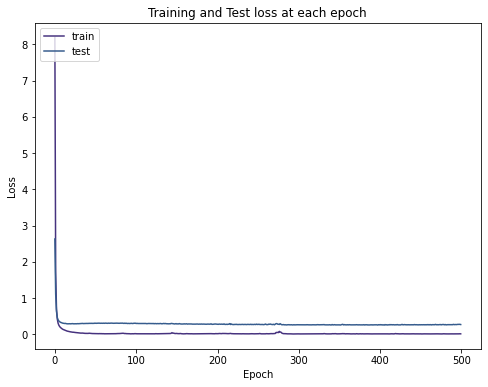

In [47]:
#evaluate model
loss_train = model_history.history['loss']
loss_val = model_history.history['val_loss']
plt.figure(figsize=(8,6))
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('Training and Test loss at each epoch')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [48]:
score_train = model.evaluate(X_train, y_train, verbose = 0)
score_test = model.evaluate(X_test, y_test, verbose = 0)

train_r2 = round(score_train[1], 4)
test_r2 = round(score_test[1], 4)
train_mse = round(score_train[0], 4)
test_mse = round(score_test[0], 4)

metrics_df = appendToMetricsdf(metrics_df, "Neural Network", train_r2, test_r2, train_mse, test_mse)

## Evaluate the Results

Let's take a look at our results and compare them with each other.

In [49]:
metrics_df

,Model Name,r-squared train,r-squared train test,MSE train,MSE test
0,AdaBoost regressor,0.4804,0.4407,0.3275,0.3551
1,Gradient Boosting,0.8149,0.7033,0.1167,0.1884
2,Extreme Gradient Boosting,0.7093,0.6544,0.1832,0.2195
3,Neural Network,0.9713,0.5086,0.0142,0.2719


The AdaBoost regressor showed bad r2 score. The predictions of this model are not similar to the real values.
Gradient Boosting and Extreme Gradient Boosting showed similar results, but Gradient Boosting is slightly better.
Finally, I trained a neural network that performs worse than Gradient Boosting and shows overfitting.

## Thank you!